# EDA SECOND PART

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_csv('masterfiles/all_users_all_metrics.csv')

In [3]:
df.dtypes

user_id                                           int64
date                                             object
overall_score_previous_day                      float64
deep_sleep_in_minutes_previous_day              float64
overall_score                                   float64
deep_sleep_in_minutes                           float64
oxygen_saturation_average_value                 float64
oxygen_saturation_average_value_previous_day    float64
rmssd                                           float64
rmssd_previous_day                              float64
daily_respiratory_rate                          float64
daily_respiratory_rate_previous_day             float64
dq_stress level                                 float64
dq_anxiety level                                float64
dtype: object

## Add a column for the university

In [4]:
df["user_id"] = df["user_id"].astype(str)
user_id_num = pd.to_numeric(df["user_id"], errors="coerce")

# --- Add 'university' column ---
df["university"] = np.where((user_id_num >= 1) & (user_id_num <= 20), "ITESM", "IPN")

In [5]:
# check for user 21
df[df["user_id"] == "21"].head()

,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level,university
1218,21,2025-02-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,50.0,IPN
1219,21,2025-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,51.0,IPN
1220,21,2025-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,51.0,IPN
1221,21,2025-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,60.0,IPN
1222,21,2025-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,40.0,IPN


## 1. Before vs After the Stress and Anxiety Chat

In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

col_stress  = "dq_stress level"
col_anxiety = "dq_anxiety level"
col_overall = "overall_score_previous_day"

# average across all users by day
daily = df.groupby("date")[[col_stress, col_anxiety, col_overall]].mean().reset_index()

cutoff = pd.Timestamp("2025-05-29")


### Stress

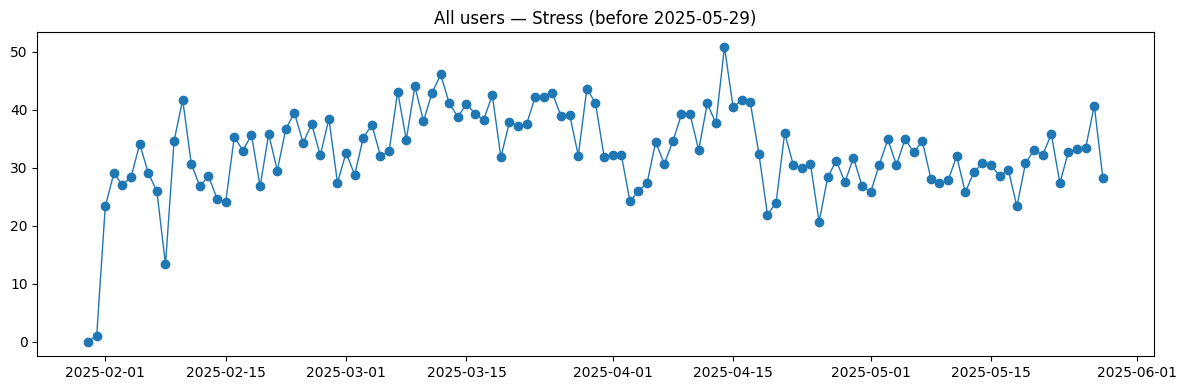

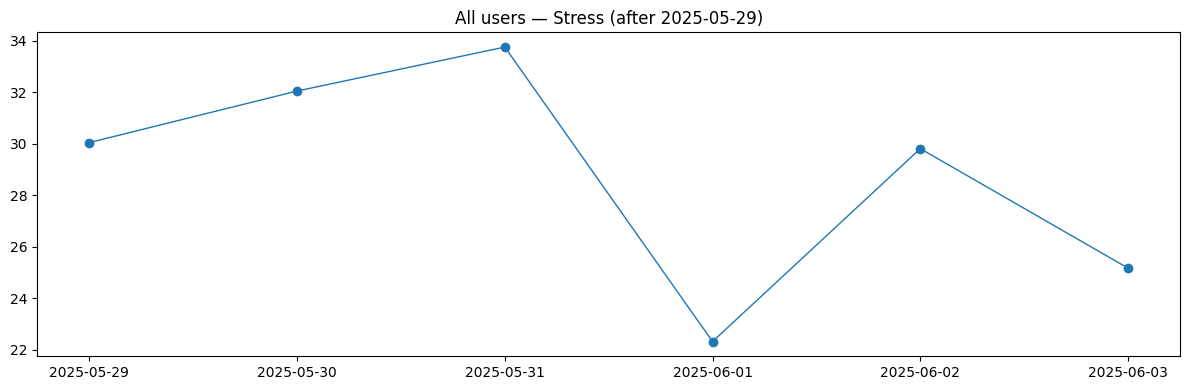

In [7]:
# before
tmp = daily[daily["date"] < cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_stress], marker="o", linewidth=1)
plt.title(f"All users — Stress (before {cutoff.date()})")
plt.tight_layout()
plt.show()

# after
tmp = daily[daily["date"] >= cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_stress], marker="o", linewidth=1)
plt.title(f"All users — Stress (after {cutoff.date()})")
plt.tight_layout()
plt.show()


### Anxiety

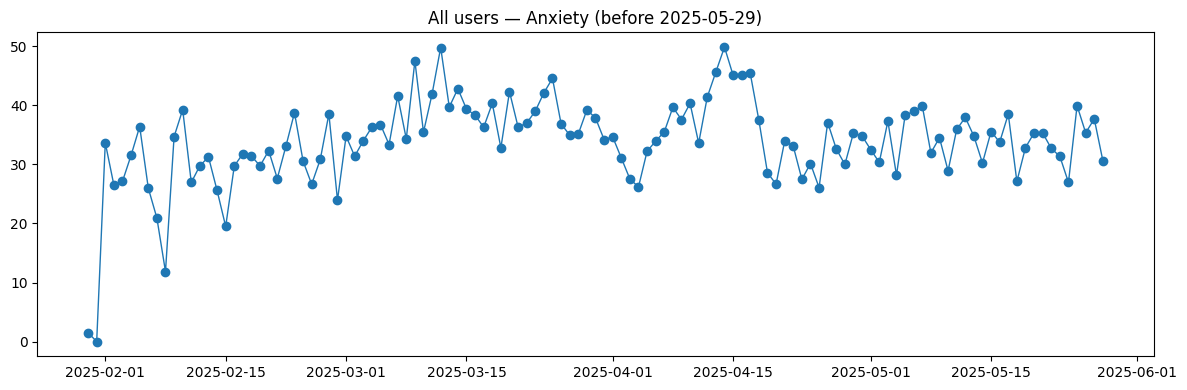

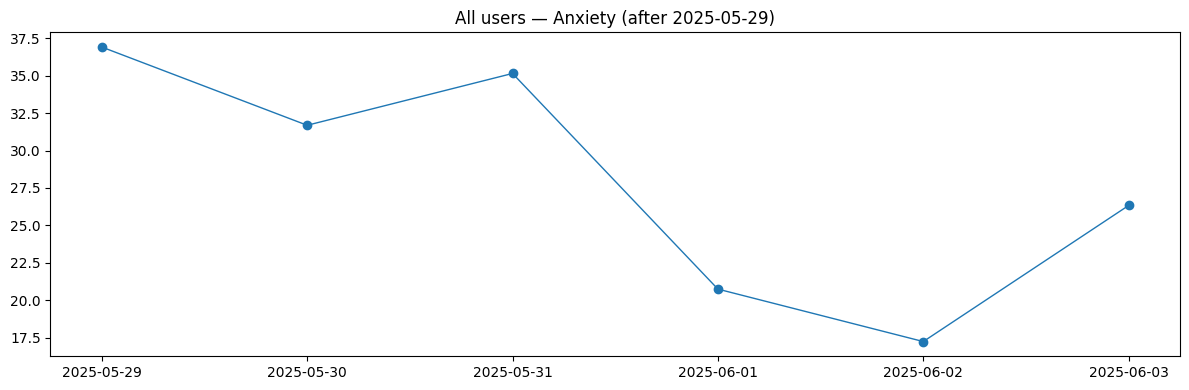

In [8]:
# before
tmp = daily[daily["date"] < cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_anxiety], marker="o", linewidth=1)
plt.title(f"All users — Anxiety (before {cutoff.date()})")
plt.tight_layout()
plt.show()

# after
tmp = daily[daily["date"] >= cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_anxiety], marker="o", linewidth=1)
plt.title(f"All users — Anxiety (after {cutoff.date()})")
plt.tight_layout()
plt.show()


### Overall Score

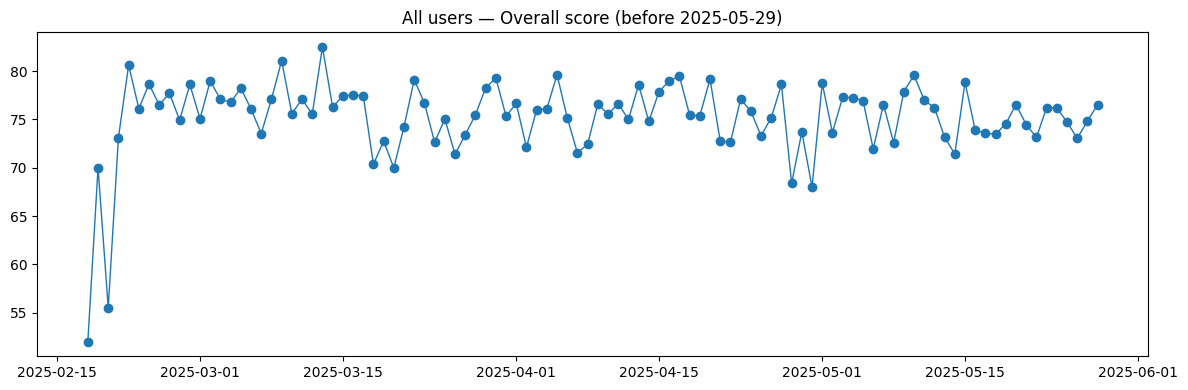

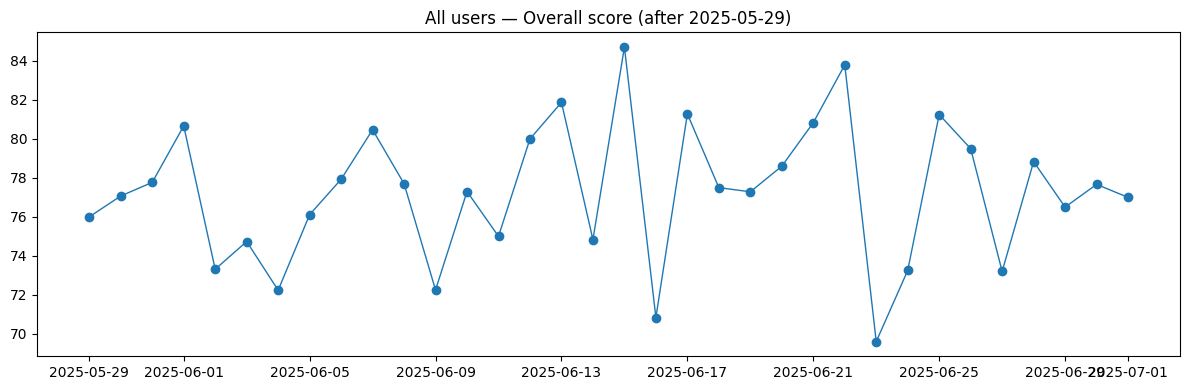

In [9]:
# before
tmp = daily[daily["date"] < cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_overall], marker="o", linewidth=1)
plt.title(f"All users — Overall score (before {cutoff.date()})")
plt.tight_layout()
plt.show()

# after
tmp = daily[daily["date"] >= cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_overall], marker="o", linewidth=1)
plt.title(f"All users — Overall score (after {cutoff.date()})")
plt.tight_layout()
plt.show()


### Stress vs Anxiety

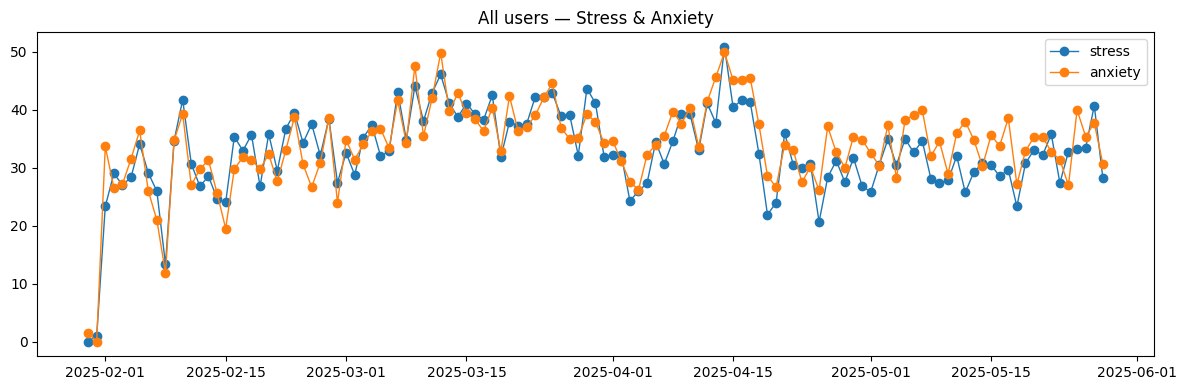

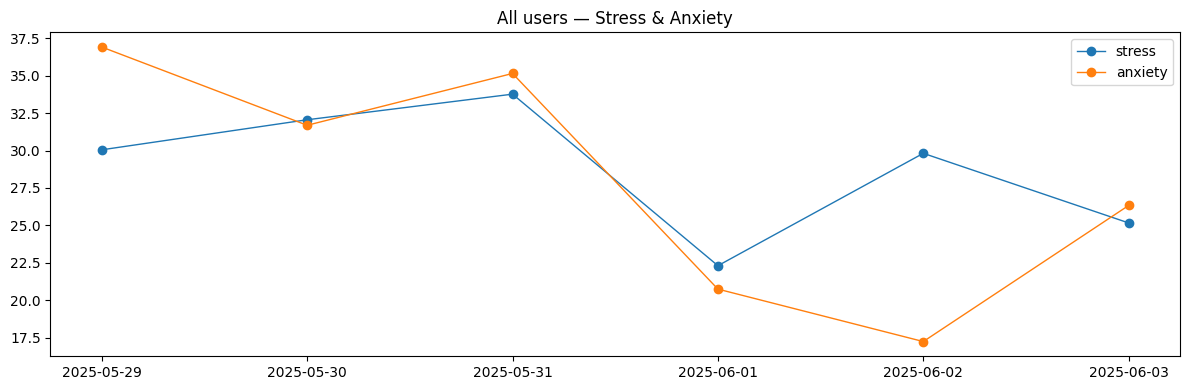

In [10]:
# before
tmp = daily[daily["date"] < cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_stress],  marker="o", linewidth=1, label="stress")
plt.plot(tmp["date"], tmp[col_anxiety], marker="o", linewidth=1, label="anxiety")
plt.title(f"All users — Stress & Anxiety")
plt.legend()
plt.tight_layout()
plt.show()

# after
tmp = daily[daily["date"] >= cutoff]
plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp[col_stress],  marker="o", linewidth=1, label="stress")
plt.plot(tmp["date"], tmp[col_anxiety], marker="o", linewidth=1, label="anxiety")
plt.title(f"All users — Stress & Anxiety")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Weekdays Heatmap

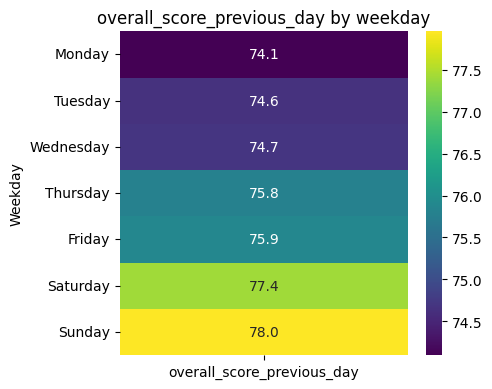

In [11]:
# make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

# pick the metric to plot
col = "overall_score_previous_day"

# weekday order
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# compute mean by weekday
tmp = df.assign(weekday=df["date"].dt.day_name())
mean_by_wd = (
    tmp.groupby("weekday")[col]
       .mean()
       .reindex(weekday_order)
       .to_frame(name=col)              
)

# heatmap 
plt.figure(figsize=(5,4))
sns.heatmap(mean_by_wd, annot=True, fmt=".1f", cmap="viridis", cbar=True)
plt.title(f"{col} by weekday")
plt.ylabel("Weekday")
plt.xlabel("")
plt.tight_layout()
plt.show()


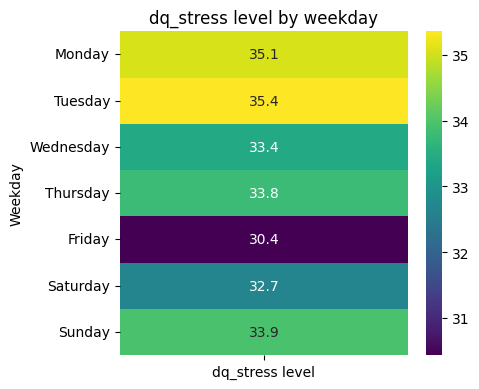

In [12]:
# make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

# pick the metric to plot
col = "dq_stress level"

# weekday order
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# compute mean by weekday
tmp = df.assign(weekday=df["date"].dt.day_name())
mean_by_wd = (
    tmp.groupby("weekday")[col]
       .mean()
       .reindex(weekday_order)
       .to_frame(name=col)              
)

# heatmap 
plt.figure(figsize=(5,4))
sns.heatmap(mean_by_wd, annot=True, fmt=".1f", cmap="viridis", cbar=True)
plt.title(f"{col} by weekday")
plt.ylabel("Weekday")
plt.xlabel("")
plt.tight_layout()
plt.show()

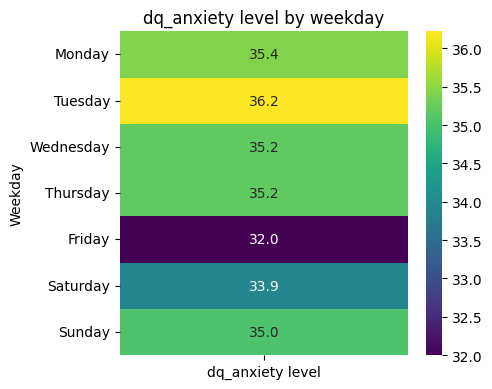

In [13]:
# make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

# pick the metric to plot
col = "dq_anxiety level"

# weekday order
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# compute mean by weekday
tmp = df.assign(weekday=df["date"].dt.day_name())
mean_by_wd = (
    tmp.groupby("weekday")[col]
       .mean()
       .reindex(weekday_order)
       .to_frame(name=col)              
)

# heatmap 
plt.figure(figsize=(5,4))
sns.heatmap(mean_by_wd, annot=True, fmt=".1f", cmap="viridis", cbar=True)
plt.title(f"{col} by weekday")
plt.ylabel("Weekday")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 3. ITESM vs IPN Analysis

In [14]:
# basic typing (safe if already done)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df["user_id"] = df["user_id"].astype(str)

# main metrics
col_overall = "overall_score_previous_day"
col_stress  = "dq_stress level"
col_anxiety = "dq_anxiety level"
col_deep    = "deep_sleep_in_minutes"


In [15]:
print("\nUsers per university:")
print(df.groupby("university")["user_id"].nunique())
print("\nRows per university:")
print(df["university"].value_counts())


Users per university:
university
IPN      15
ITESM    20
Name: user_id, dtype: int64

Rows per university:
university
ITESM    1946
IPN      1521
Name: count, dtype: int64


### Summaries

In [16]:
# means by university for ALL numeric columns
num_cols = df.select_dtypes(include="number").columns
uni_means = df.groupby("university")[num_cols].mean().round(2)
print("Means by university (all numeric):")
print(uni_means)


Means by university (all numeric):
            overall_score_previous_day  deep_sleep_in_minutes_previous_day  overall_score  deep_sleep_in_minutes  \
university                                                                                                         
IPN                              76.35                               76.77          76.74                  77.33   
ITESM                            75.16                               77.26          75.28                  77.66   

            oxygen_saturation_average_value  oxygen_saturation_average_value_previous_day  rmssd  rmssd_previous_day  \
university                                                                                                             
IPN                                   94.72                                         94.76  60.87               60.68   
ITESM                                 95.08                                         95.12  73.23               74.21   

            daily_r

### Trends by University

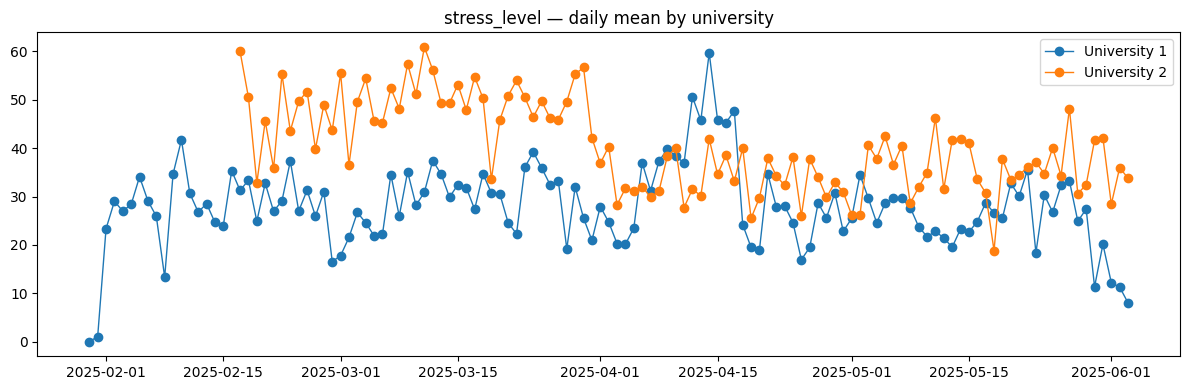

In [17]:
daily_uni = (
    df.groupby(["date", "university"])[[col_stress]]
      .mean()
      .reset_index()
)

university_map = {
    "ITESM": "University 1",
    "IPN": "University 2"
}

clean_col_name = col_stress.replace("dq_", "").replace(" ", "_")

plt.figure(figsize=(12, 4))

for uni in ["ITESM", "IPN"]:
    tmp = daily_uni[daily_uni["university"] == uni]
    plt.plot(
        tmp["date"],
        tmp[col_stress],
        marker="o",
        linewidth=1,
        label=university_map[uni]
    )

plt.title(f"{clean_col_name} — daily mean by university")
plt.legend()
plt.tight_layout()
plt.show()

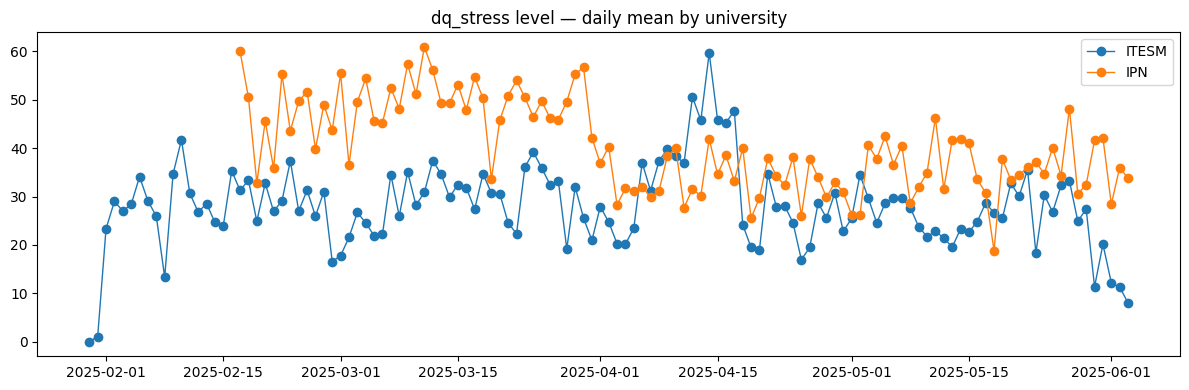

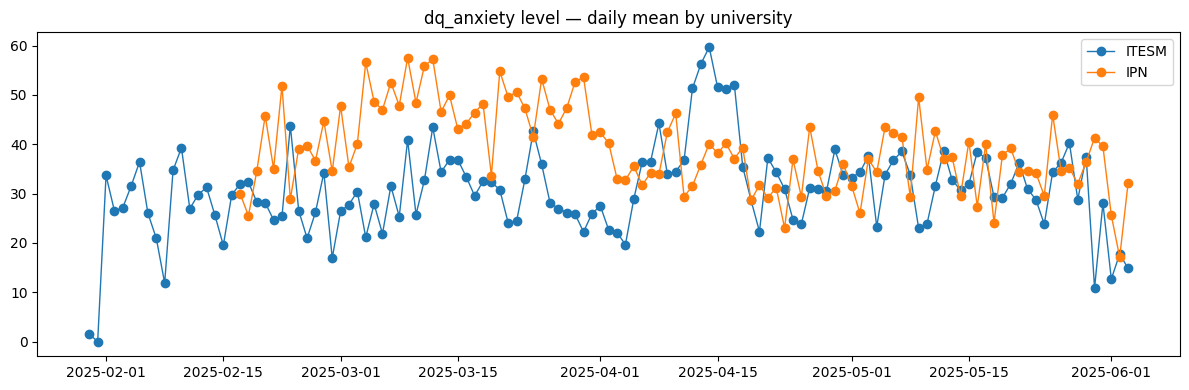

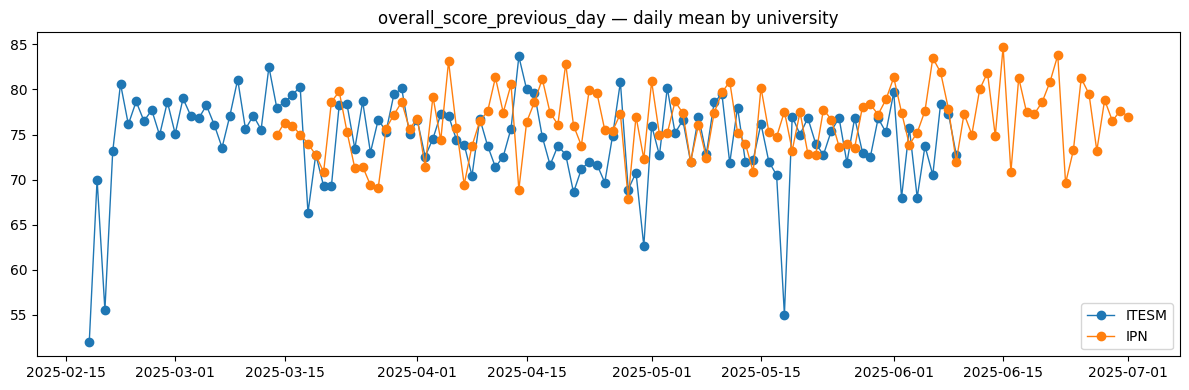

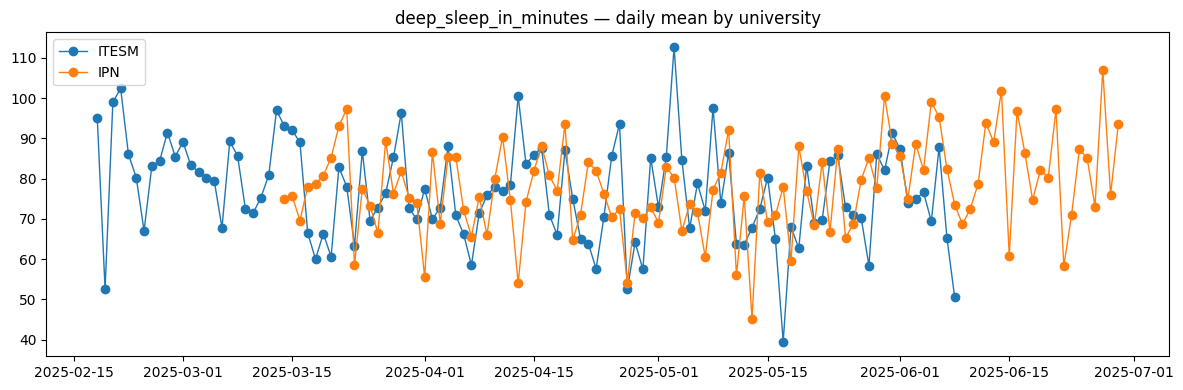

In [18]:
daily_uni = (
    df.groupby(["date","university"])[[col_stress, col_anxiety, col_overall, col_deep]]
      .mean()
      .reset_index()
)

for col in [col_stress, col_anxiety, col_overall, col_deep]:
    plt.figure(figsize=(12,4))
    for uni in ["ITESM","IPN"]:
        tmp = daily_uni[daily_uni["university"] == uni]
        plt.plot(tmp["date"], tmp[col], marker="o", linewidth=1, label=uni)
    plt.title(f"{col} — daily mean by university")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Distributions

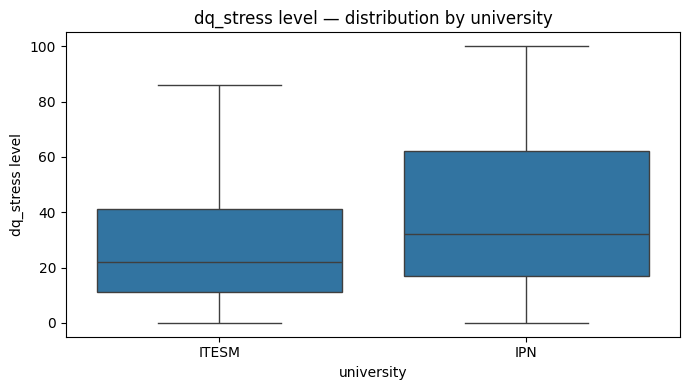

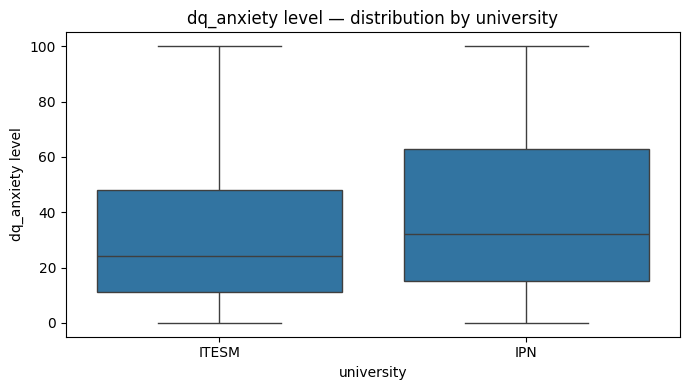

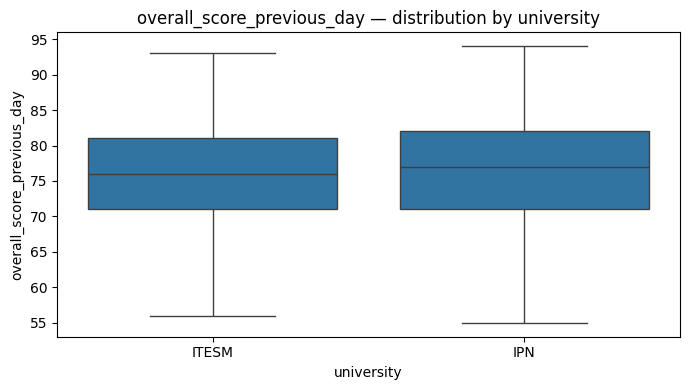

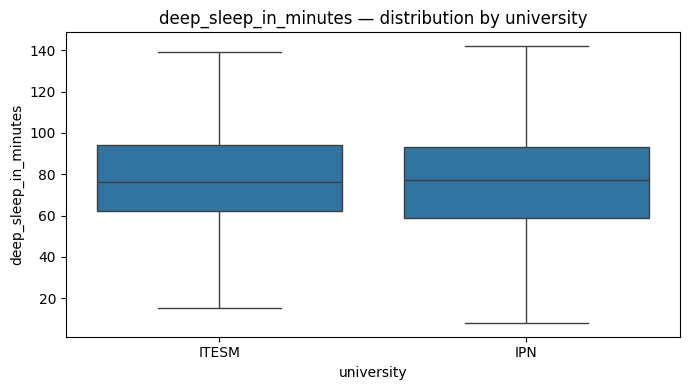

In [19]:
for col in [col_stress, col_anxiety, col_overall, col_deep]:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="university", y=col, showfliers=False)
    plt.title(f"{col} — distribution by university")
    plt.tight_layout()
    plt.show()


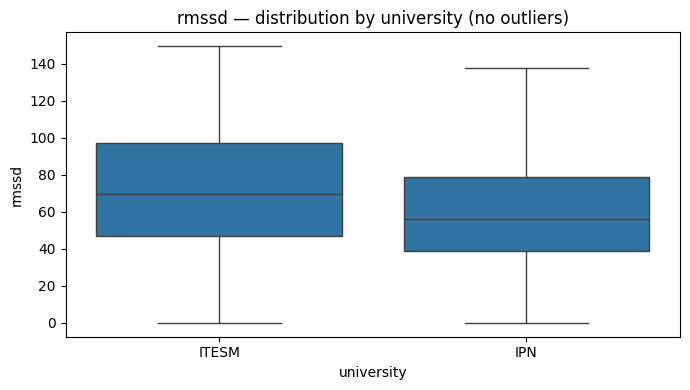

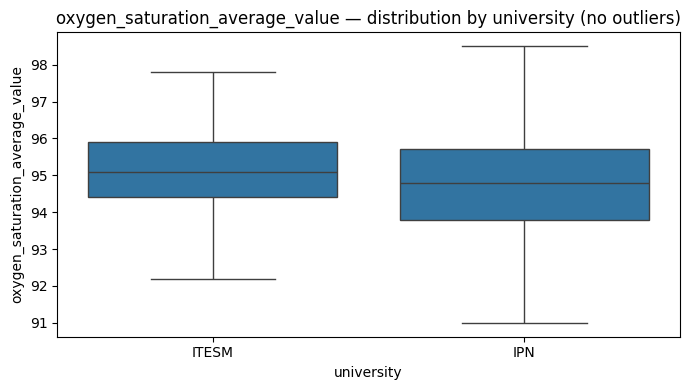

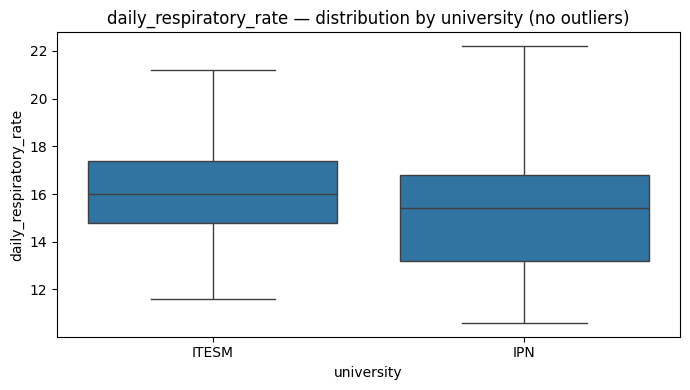

In [20]:
# all numeric except the main ones
num_cols = df.select_dtypes(include="number").columns.tolist()
other_vars = ['rmssd', 'oxygen_saturation_average_value', 'daily_respiratory_rate']  # Example other variables

# keep it short: take the first 7 "other" variables (change this list as you like)
vars_for_boxplot = other_vars[:7]

for v in vars_for_boxplot:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="university", y=v, showfliers=False)
    plt.title(f"{v} — distribution by university (no outliers)")
    plt.tight_layout()
    plt.show()

### Trends by weekdays

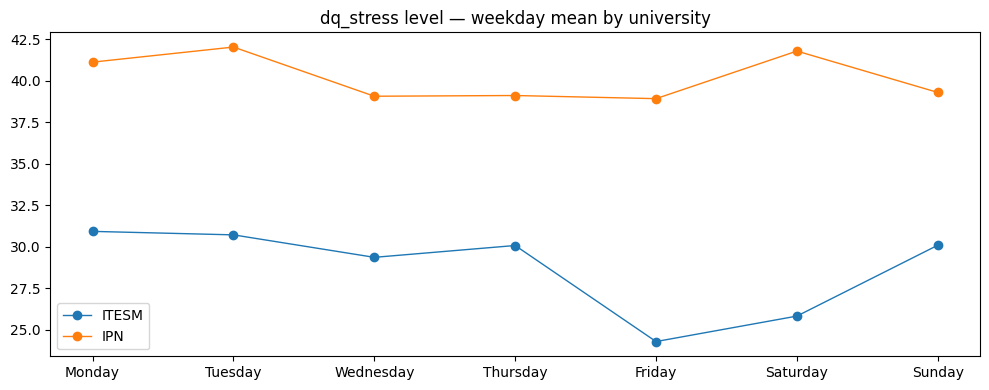

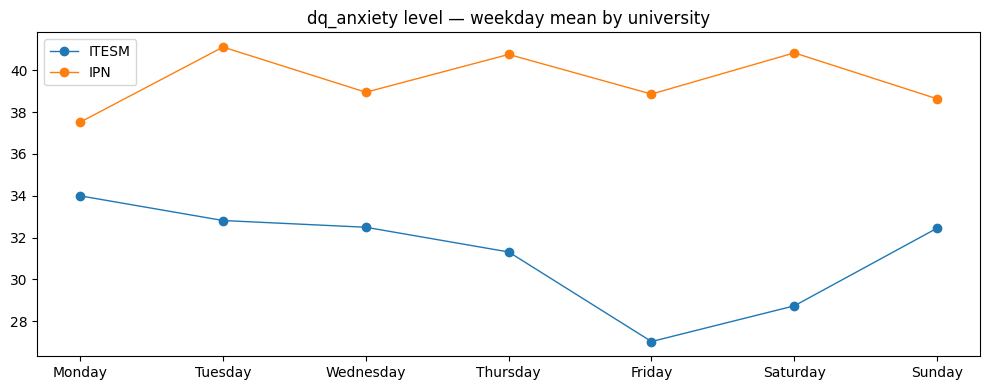

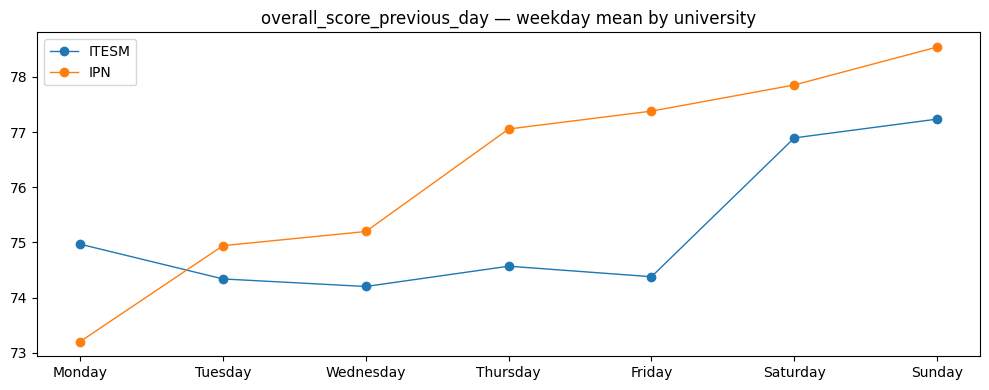

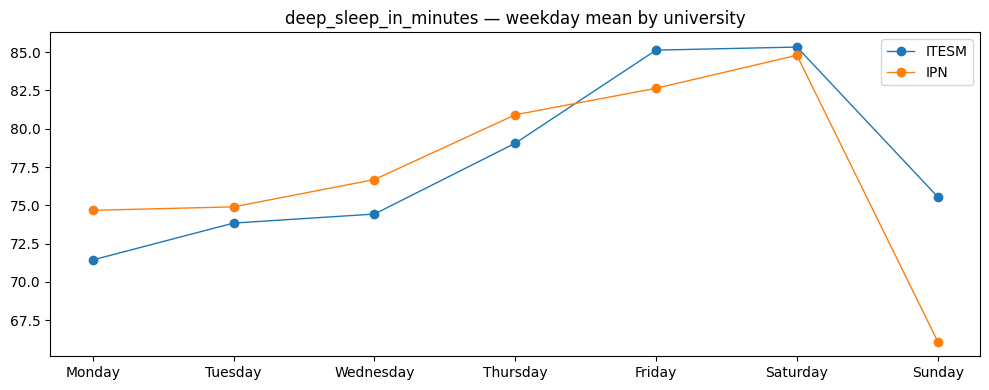

In [21]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["weekday"] = df["date"].dt.day_name()

wd = (
    df.groupby(["weekday","university"])[[col_stress, col_anxiety, col_overall, col_deep]]
      .mean()
      .reset_index()
)

for col in [col_stress, col_anxiety, col_overall, col_deep]:
    plt.figure(figsize=(10,4))
    for uni in ["ITESM","IPN"]:
        tmp = wd[wd["university"] == uni].set_index("weekday").reindex(weekday_order)
        plt.plot(weekday_order, tmp[col].values, marker="o", linewidth=1, label=uni)
    plt.title(f"{col} — weekday mean by university")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [22]:
for uni in ["ITESM","IPN"]:
    sub = df[df["university"] == uni][top_vars].dropna()
    if sub.shape[1] == 0:
        continue
    corr = sub.corr()
    plt.figure(figsize=(4 + 0.5*len(top_vars), 4 + 0.5*len(top_vars)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", cbar=True)
    plt.title(f"{uni} — correlation (top 'other' vars)")
    plt.tight_layout()
    plt.show()


NameError: name 'top_vars' is not defined

## 3.1 Holy Week Analysis

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

col_stress  = "dq_stress level"
col_anxiety = "dq_anxiety level"
col_overall = "overall_score_previous_day"

# separate by university
itesm_df = df[df["university"] == "ITESM"].copy()
ipn_df   = df[df["university"] == "IPN"].copy()

# holiday windows
itesm_start, itesm_end = pd.Timestamp("2025-04-13"), pd.Timestamp("2025-04-20")
ipn_start,   ipn_end   = pd.Timestamp("2025-04-17"), pd.Timestamp("2025-04-25")


In [ ]:
# group by day for each university
itesm_daily = itesm_df.groupby("date")[[col_stress, col_anxiety, col_overall]].mean().reset_index()
ipn_daily   = ipn_df.groupby("date")[[col_stress, col_anxiety, col_overall]].mean().reset_index()


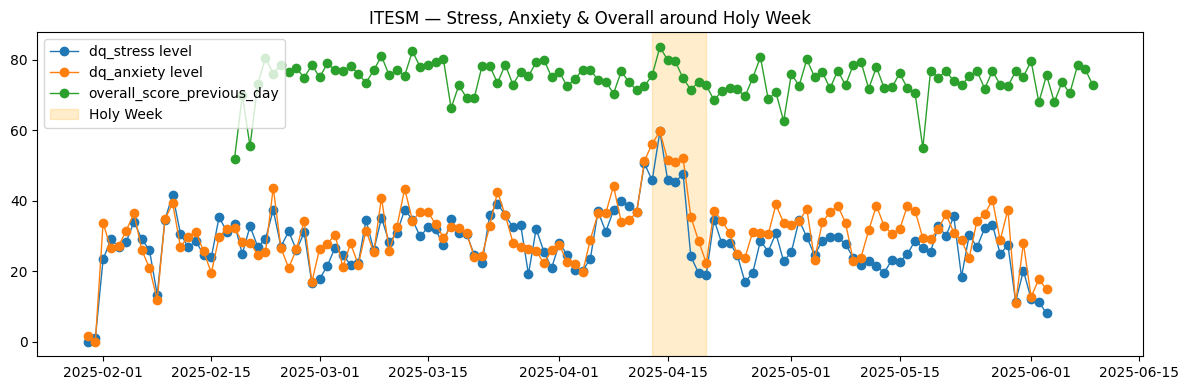

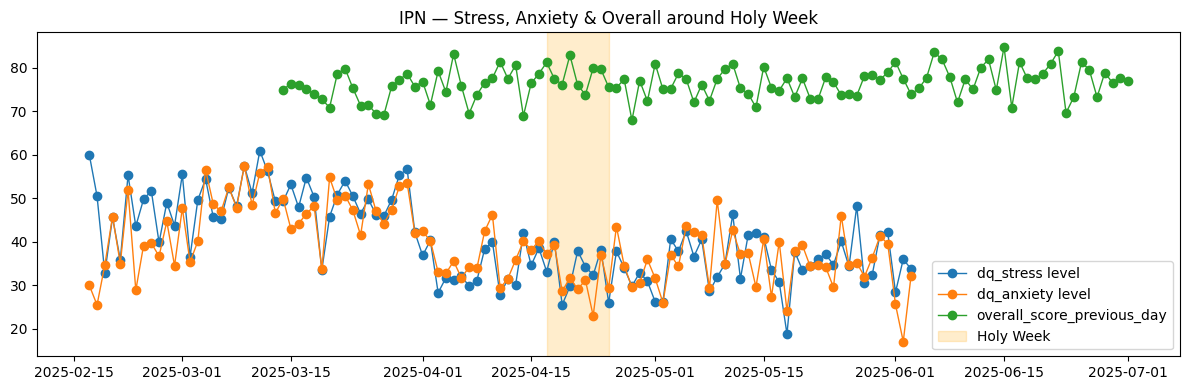

In [ ]:
def plot_holyweek(daily, uni, start, end):
    plt.figure(figsize=(12,4))
    for col in [col_stress, col_anxiety, col_overall]:
        plt.plot(daily["date"], daily[col], marker="o", linewidth=1, label=col)
    plt.axvspan(start, end, color="orange", alpha=0.2, label="Holy Week")
    plt.title(f"{uni} — Stress, Anxiety & Overall around Holy Week")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_holyweek(itesm_daily, "ITESM", itesm_start, itesm_end)
plot_holyweek(ipn_daily,   "IPN",   ipn_start,   ipn_end)


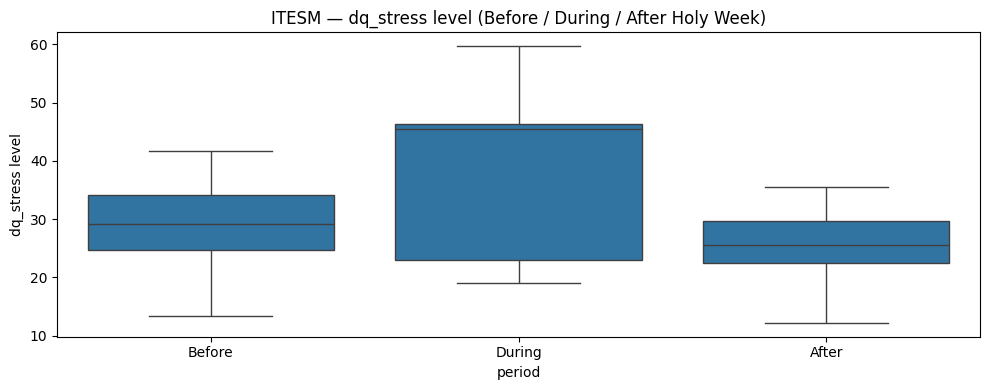

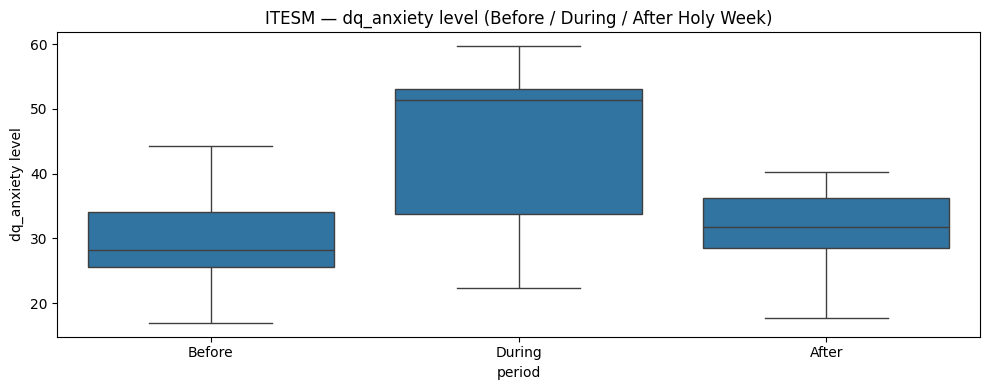

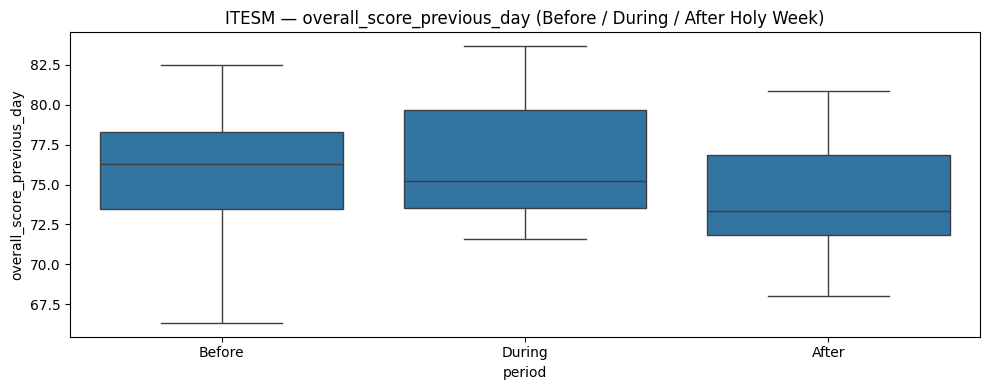

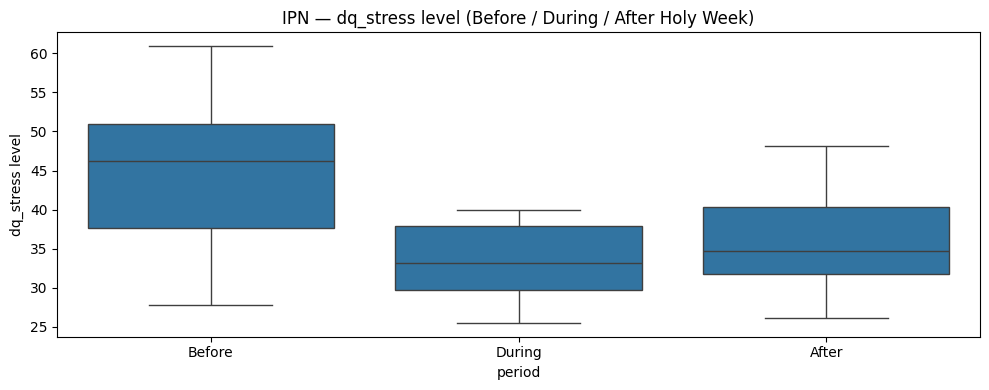

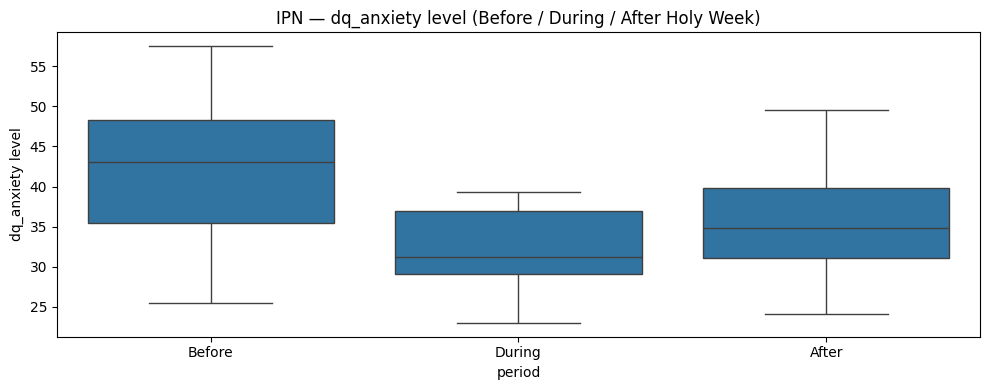

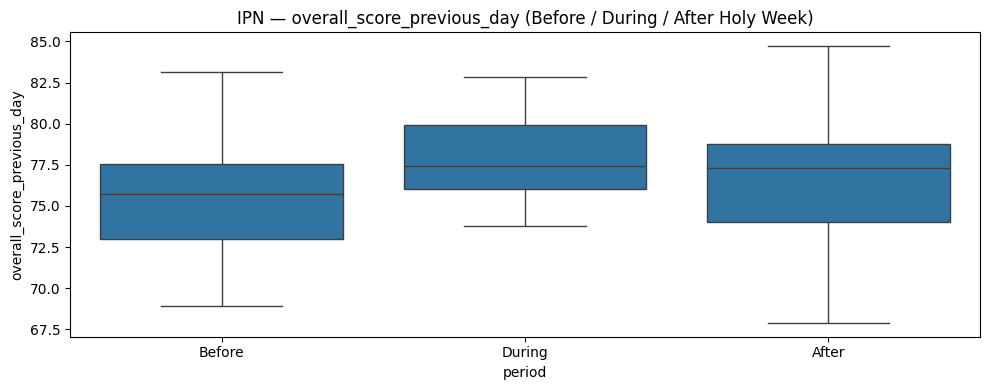

In [ ]:
# helper (already defined earlier)
def split_periods(daily_df, start, end):
    def label_period(d):
        if d < start: return "Before"
        elif d > end: return "After"
        else: return "During"
    return daily_df.assign(period=daily_df["date"].apply(label_period))

metrics = [col_stress, col_anxiety, col_overall]

# ITESM (no outliers)
itesm_periods = split_periods(itesm_daily, itesm_start, itesm_end)
for m in metrics:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=itesm_periods, x="period", y=m, showfliers=False)
    plt.title(f"ITESM — {m} (Before / During / After Holy Week)")
    plt.tight_layout()
    plt.show()

# IPN (no outliers)
ipn_periods = split_periods(ipn_daily, ipn_start, ipn_end)
for m in metrics:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=ipn_periods, x="period", y=m, showfliers=False)
    plt.title(f"IPN — {m} (Before / During / After Holy Week)")
    plt.tight_layout()
    plt.show()



## Summary Stats before vs during vs after

In [ ]:
try:
    _itesm_source = itesm_df.copy()
    _ipn_source   = ipn_df.copy()
except NameError:
    _itesm_source = df[df["university"] == "ITESM"].copy()
    _ipn_source   = df[df["university"] == "IPN"].copy()

def daily_all_numeric(source):
    num_cols = source.select_dtypes(include="number").columns
    return source.groupby("date")[num_cols].mean().reset_index()

def period_label(d, start, end):
    if d < start: return "Before"
    elif d > end: return "After"
    else: return "During"

# Build daily (all numeric) per uni
itesm_daily_all = daily_all_numeric(_itesm_source)
ipn_daily_all   = daily_all_numeric(_ipn_source)

# Add period labels (uses your existing itesm_start/itesm_end/ipn_start/ipn_end)
itesm_periods = itesm_daily_all.assign(
    period=itesm_daily_all["date"].apply(lambda d: period_label(d, itesm_start, itesm_end))
)
ipn_periods = ipn_daily_all.assign(
    period=ipn_daily_all["date"].apply(lambda d: period_label(d, ipn_start, ipn_end))
)

def summary_table(period_df):
    num_cols = period_df.select_dtypes(include="number").columns.drop("period", errors="ignore")
    return period_df.groupby("period")[num_cols].mean().round(2).sort_index()




### ITESM

In [ ]:
print("ITESM — mean by period (ALL numeric columns):")
print(summary_table(itesm_periods))



ITESM — mean by period (ALL numeric columns):
        overall_score_previous_day  deep_sleep_in_minutes_previous_day  overall_score  deep_sleep_in_minutes  \
period                                                                                                         
After                        73.55                               74.37          73.54                  73.86   
Before                       75.04                               78.09          75.26                  78.62   
During                       76.47                               84.82          75.95                  82.07   

        oxygen_saturation_average_value  oxygen_saturation_average_value_previous_day  rmssd  rmssd_previous_day  daily_respiratory_rate  \
period                                                                                                                                     
After                             95.08                                         95.10  71.68               70.53 

### IPN

In [ ]:

print("\nIPN — mean by period (ALL numeric columns):")
print(summary_table(ipn_periods))


IPN — mean by period (ALL numeric columns):
        overall_score_previous_day  deep_sleep_in_minutes_previous_day  overall_score  deep_sleep_in_minutes  \
period                                                                                                         
After                        76.70                               78.02          76.96                  78.23   
Before                       75.38                               75.11          76.03                  76.74   
During                       78.04                               79.22          77.53                  77.74   

        oxygen_saturation_average_value  oxygen_saturation_average_value_previous_day  rmssd  rmssd_previous_day  daily_respiratory_rate  \
period                                                                                                                                     
After                             94.80                                         94.86  62.53               62.30  